### Week 4 notebook - Logistic Regression and Feature Scaling, Mod C Data Science Capstone Fall 2026
### By Shuqin Ouyang

# Overall notebook structure:

This week uses logistic regression directly on the real 0/1 target, no binning workaround needed, since logistic regression is the actual correct tool for a binary outcome. Hypothesis A fits L1-penalized logistic regression on the full feature set to automatically select the most useful features (the same elimination behavior Lasso showed in Week 2, now on a classifier), checks whether that selection is consistent across cross-validation folds, checks for outliers among the selected features (this week's lesson notes log-loss does not protect against outliers the way you might expect), then compares scaling methods and tunes the regularization strength C. Hypothesis B deliberately tests a known-redundant feature pair, the same multicollinearity vulnerability the lesson describes for linear regression, grounded in real VIF numbers already confirmed in earlier weeks, comparing severity between the two datasets. Credit card dataset also gets a quick check on whether adjacent months are independent samples, directly testing this week's lesson point about repeated, correlated measurements over time.

# Student dataset analysis starts here:

Dataset 1 background quick overview:

The dataset 1 used is the Taiwanese Bankruptcy Prediction dataset from UCI, link as https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction.
It contains company financial indicators and a binary outcome for bankruptcy.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import f1_score, precision_score, recall_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [2]:
# install uci package so can load the data using package
# install once in terminal or notebook

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# load dataset from UCI repository using dataset id
data_bankruptcy = fetch_ucirepo(id=572)

df_bankruptcy = pd.concat(
    [data_bankruptcy.data.features.copy(),
     data_bankruptcy.data.targets.copy()],
    axis=1
)

# remove leading/trailing spaces from column names once, here
df_bankruptcy.columns = df_bankruptcy.columns.str.strip()

df_bankruptcy.head()

'pip' is not recognized as an internal or external command,
operable program or batch file.


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Bankrupt?
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794,1
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474,1
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982,1
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490,1


In [3]:
# show dataset info
df_bankruptcy.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 1   ROA(A) before interest and % after tax                   6819 non-null   float64
 2   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 3   Operating Gross Margin                                   6819 non-null   float64
 4   Realized Sales Gross Margin                              6819 non-null   float64
 5   Operating Profit Rate                                    6819 non-null   float64
 6   Pre-tax net Interest Rate                                6819 non-null   float64
 7   After-tax net Interest Rate                              6819 non-null   float64
 8   Non-industry income and expenditure/rev

In [4]:
def check_vif(X):
    ''' VIF (Variance Inflation Factor): for each feature, how well can
    it be predicted from the OTHER features combined? A high VIF (e.g.
    >5) means that feature is redundant, it carries mostly the same
    information as some combination of the others, same method used
    from earlier weeks '''
    X_const = sm.add_constant(X)
    vif_data = pd.DataFrame({
        'Feature': X_const.columns,
        'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    })
    return vif_data

In [5]:
def check_overfitting_f1(model, X_train, y_train, label):
    ''' same design as Week 3's overfitting check, but using F1 instead
    of R2/accuracy, since .score() on a classifier returns accuracy by
    default, not the metric this week actually cares about '''
    train_f1 = f1_score(y_train, model.predict(X_train))
    cv_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    print(f"{label}: train F1 = {train_f1:.4f}, CV F1 = {cv_f1.mean():.4f}, gap = {train_f1 - cv_f1.mean():.4f}")
    return train_f1, cv_f1.mean()

In [6]:
def compare_scaling(X, y, label):
    ''' fit logistic regression three ways on the same train/test split:
    unscaled, standardized (X = (X - mean) / std), and normalized
    (X = (X - min) / (max - min)), print coefficients side by side, and
    return the split data plus the standardized version and the
    coefficient table itself, so later steps like hyperparameter tuning
    or plotting can reuse them directly '''
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model_unscaled = LogisticRegression(max_iter=1000).fit(X_train, y_train)

    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)
    X_test_std = scaler.transform(X_test)
    model_standardized = LogisticRegression(max_iter=1000).fit(X_train_std, y_train)

    minmax = MinMaxScaler()
    X_train_norm = minmax.fit_transform(X_train)
    model_normalized = LogisticRegression(max_iter=1000).fit(X_train_norm, y_train)

    coef_table = pd.DataFrame({
        'unscaled': model_unscaled.coef_[0],
        'standardized': model_standardized.coef_[0],
        'normalized': model_normalized.coef_[0]
    }, index=X.columns)
    print(f"{label} scaling comparison:")
    print(coef_table)

    return X_train, X_test, y_train, y_test, X_train_std, X_test_std, coef_table

In [7]:
def test_redundant_pair(X, y, label):
    ''' fit logistic regression on features already known to be
    redundant (confirmed by VIF), to see how the model handles that
    redundancy, does it split credit evenly, shrink one toward zero,
    or something in between. Also checks overfitting and recomputes
    VIF for direct evidence of how redundant these features actually
    are '''
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
    print(f"{label} coefficients:")
    print(pd.Series(model.coef_[0], index=X.columns))

    check_overfitting_f1(model, X_train_scaled, y_train, label)

    vif = check_vif(X)
    print(vif)

Student markdown:

For this test, I wanted to see how logistic regression handles the real 0/1 target directly, instead of the binned-rate workaround I've used every week so far. I fit L1-penalized logistic regression on the full 96-feature bankruptcy dataset, letting the model pick which features actually matter on its own, the same elimination behavior Lasso showed in Week 2, just applied to a classifier this time.

In [8]:
# Hypothesis A: fit L1-penalized logistic regression on the full
# feature set, the same elimination behavior Lasso showed in Week 2,
# now on a classifier. Non-zero coefficients are the selected features.
# Scaling first helps avoid a convergence problem too, unscaled features
# with wildly different sizes can make the solver struggle to settle.
# Using liblinear (fast for L1) instead of saga (much slower here)
target_bankrupt = 'Bankrupt?'
X_full_bankrupt = df_bankruptcy.drop(columns=[target_bankrupt]).dropna()
y_bankrupt = df_bankruptcy.loc[X_full_bankrupt.index, target_bankrupt]
print("Rows available after dropping missing values:", len(X_full_bankrupt))

scaler_full_bankrupt = StandardScaler()
X_full_bankrupt_scaled = scaler_full_bankrupt.fit_transform(X_full_bankrupt)

l1_model_bankrupt = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
l1_model_bankrupt.fit(X_full_bankrupt_scaled, y_bankrupt)
selected_bankrupt = X_full_bankrupt.columns[l1_model_bankrupt.coef_[0] != 0].tolist()
print(f"{len(selected_bankrupt)} features selected:", selected_bankrupt)

# check whether L1 picks the same features across folds, or if the set
# shifts depending on which fold we get
cv_results_bankrupt = cross_validate(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000),
    X_full_bankrupt_scaled, y_bankrupt, cv=5, return_estimator=True
)

fold_num = 1
for model in cv_results_bankrupt['estimator']:
    selected = X_full_bankrupt.columns[model.coef_[0] != 0].tolist()
    print(f"Fold {fold_num}: {len(selected)} features selected:", selected)
    fold_num = fold_num + 1

# quick outlier check on the selected features, log-loss does not
# protect against outliers the way you might expect
print(df_bankruptcy[selected_bankrupt].describe())

Rows available after dropping missing values: 6819


c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


74 features selected: ['ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'Realized Sales Gross Margin', 'Operating Profit Rate', 'Non-industry income and expenditure/revenue', 'Operating Expense Rate', 'Research and development expense rate', 'Cash flow rate', 'Tax rate (A)', 'Net Value Per Share (B)', 'Persistent EPS in the Last Four Seasons', 'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)', 'Per Share Net profit before tax (Yuan ¥)', 'Realized Sales Gross Profit Growth Rate', 'Operating Profit Growth Rate', 'Regular Net Profit Growth Rate', 'Continuous Net Profit Growth Rate', 'Total Asset Growth Rate', 'Net Value Growth Rate', 'Cash Reinvestment %', 'Quick Ratio', 'Interest Expense Ratio', 'Total debt/Total net worth', 'Debt ratio %', 'Net worth/Assets', 'Long-term fund suitability ratio (A)', 'Borrowing dependency', 'Contingent liabilities/Net worth', 'Operating profit/Paid-in capital', 'Net profit before tax/Paid-in capital', 

c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default va

Fold 1: 68 features selected: ['ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'Realized Sales Gross Margin', 'Operating Profit Rate', 'Non-industry income and expenditure/revenue', 'Operating Expense Rate', 'Research and development expense rate', 'Cash flow rate', 'Net Value Per Share (B)', 'Persistent EPS in the Last Four Seasons', 'Cash Flow Per Share', 'Operating Profit Per Share (Yuan ¥)', 'Per Share Net profit before tax (Yuan ¥)', 'Realized Sales Gross Profit Growth Rate', 'Operating Profit Growth Rate', 'After-tax Net Profit Growth Rate', 'Continuous Net Profit Growth Rate', 'Total Asset Growth Rate', 'Net Value Growth Rate', 'Total Asset Return Growth Rate Ratio', 'Cash Reinvestment %', 'Quick Ratio', 'Interest Expense Ratio', 'Total debt/Total net worth', 'Debt ratio %', 'Net worth/Assets', 'Long-term fund suitability ratio (A)', 'Borrowing dependency', 'Contingent liabilities/Net worth', 'Operating profit/Paid-in capital'

Student markdown:

L1 selecting 74 of 96 features is a bit unexpected. Going in, I expected a stricter cut, since I know from earlier weeks that a lot of these financial ratios are similar or related to each other, and regularization should be able to remove some of that redundancy. Checking consistency across 5 folds, the selected feature count stayed in a similar range (around 68-74) but the exact set shifted a bit fold to fold, not perfectly stable. This makes sense once I think about it, with 96 features and only 6,819 rows, there's a lot of near-collinear financial ratios competing for the same signal, so which specific one gets kept can depend somewhat on the particular split.

The outlier check on the selected features was expected, earlier Mod B EDA already found several of these ratios have their mean sitting close to their max (like Operating Profit Rate at mean 0.999, max 1.0), meaning most companies cluster tightly while a few pull the range wide. This week's lesson makes an important point worth remembering: log-loss doesn't actually protect against outliers the way I might have assumed, if the linear part of the equation is very negative, the log term stays roughly that negative too. So these outlier-heavy features are a real, acknowledged risk here, not something logistic regression automatically handles.

Bankruptcy scaling comparison:
                                                        unscaled  \
ROA(C) before interest and depreciation before ... -5.981237e-13   
ROA(A) before interest and % after tax             -6.667780e-13   
Realized Sales Gross Margin                        -6.191625e-13   
Operating Profit Rate                              -9.911226e-13   
Non-industry income and expenditure/revenue        -3.038090e-13   
...                                                          ...   
Net Income to Stockholder's Equity                 -8.556172e-13   
Liability to Equity                                -2.614188e-13   
Degree of Financial Leverage (DFL)                 -2.545362e-14   
Interest Coverage Ratio (Interest expense to EBIT) -5.633587e-13   
Equity to Liability                                -8.660834e-14   

                                                    standardized  normalized  
ROA(C) before interest and depreciation before ...     -0.354809   -2.885

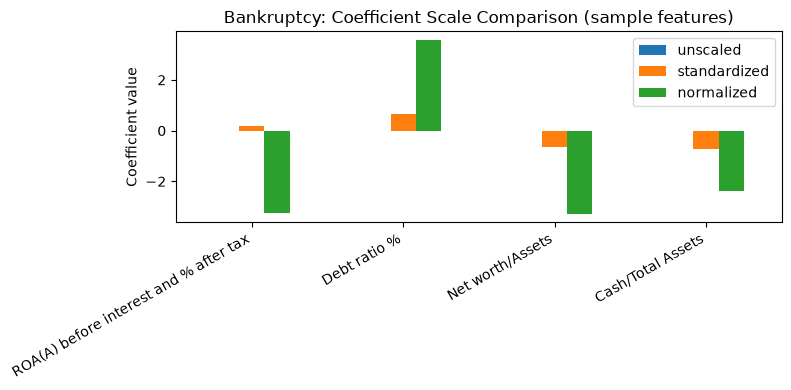

In [9]:
X_train_bankrupt, X_test_bankrupt, y_train_bankrupt, y_test_bankrupt, X_train_std_bankrupt, X_test_std_bankrupt, coef_table_bankrupt = \
    compare_scaling(df_bankruptcy[selected_bankrupt].loc[X_full_bankrupt.index], y_bankrupt, "Bankruptcy")

# chart comparing unscaled, standardized, and normalized coefficients
# for a handful of the selected features, to visualize the scale
# distortion directly rather than just reading numbers in a large table
sample_features_bankrupt = ['ROA(A) before interest and % after tax', 'Debt ratio %',
                             'Net worth/Assets', 'Cash/Total Assets']
sample_features_bankrupt = [f for f in sample_features_bankrupt if f in coef_table_bankrupt.index]

coef_table_bankrupt.loc[sample_features_bankrupt].plot(kind='bar', figsize=(8, 4))
plt.title('Bankruptcy: Coefficient Scale Comparison (sample features)')
plt.ylabel('Coefficient value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Student markdown:

The scale/no-scale difference was expected, I've already seen this same pattern in earlier weeks: unscaled coefficients are vanishingly small (around 1e-13), essentially invisible next to standardized coefficients in the more normal 0.01-0.9 range. This makes sense, since logistic regression is still a linear combination underneath the sigmoid, so the same scale-distortion problem applies here too.

What was genuinely unexpected, and visible directly on the sample-feature chart, is that normalized coefficients consistently come out larger in magnitude than standardized ones. Working through the math, this isn't a coincidence, it's actually guaranteed whenever a feature's full range (max minus min) is larger than its standard deviation, which is true for almost any real dataset. Since standardized X = (X - mean) / std and normalized X = (X - min) / (max - min), the two are just a linear rescaling of each other, and it works out that normalized_coefficient = standardized_coefficient * (max - min) / std. So the bigger a feature's range is relative to its spread, the bigger the gap between its normalized and standardized coefficient will be.

In [10]:
# hyperparameter tuning: LogisticRegressionCV tries 10 C values and
# picks the best one via cross-validation, C controls regularization
# strength (smaller C = stronger penalty), same idea as RidgeCV/LassoCV.
# No need for l1_ratios/saga here, this step just uses the default L2
# penalty, so the faster lbfgs solver works fine
model_tuned_bankrupt = LogisticRegressionCV(Cs=10, cv=5, max_iter=1000, scoring='f1')
model_tuned_bankrupt.fit(X_train_std_bankrupt, y_train_bankrupt)
print("Best C:", model_tuned_bankrupt.C_[0])

check_overfitting_f1(model_tuned_bankrupt, X_train_std_bankrupt, y_train_bankrupt, "Bankruptcy tuned logistic regression")

pred_bankrupt = model_tuned_bankrupt.predict(X_test_std_bankrupt)
print(f"F1={f1_score(y_test_bankrupt, pred_bankrupt):.4f}, precision={precision_score(y_test_bankrupt, pred_bankrupt):.4f}, "
      f"recall={recall_score(y_test_bankrupt, pred_bankrupt):.4f}")

c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.w

Best C: 0.3593813663804626


c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.w

Bankruptcy tuned logistic regression: train F1 = 0.3421, CV F1 = 0.2415, gap = 0.1006
F1=0.2769, precision=0.6429, recall=0.1765


Student markdown:

LogisticRegressionCV is what actually does the hyperparameter tuning here, it automatically tries 10 different C values and picks whichever one performs best under 5-fold cross-validation, the same automated-search idea as RidgeCV/LassoCV from Week 2, just tuning C instead of alpha. Cross-validation picked C = 0.359 as the best regularization strength.

The tuned model reached test F1 = 0.277, precision = 0.643, recall = 0.177. The precision/recall split here is telling, when the model predicts bankruptcy, it's right about 64% of the time, but it only catches about 18% of the companies that actually went bankrupt. This is exactly what I'd expect given bankruptcy's severe class imbalance (only about 3% of companies), the model plays it safe and under-predicts the rare class.

The train/CV F1 gap here is 0.101 (0.342 vs. 0.242), worth flagging honestly as a real sign of some overfitting, even after tuning C. Since L1's selected feature count also varied somewhat across folds (68-74), that instability likely contributes to the gap too, the model isn't only overfitting the coefficients, it's also somewhat uncertain about which features to even use.

In [11]:
# Hypothesis B: test a pair already known to be near-duplicates (from
# earlier VIF work), to see if logistic regression shows the same
# multicollinearity instability the lesson describes for linear
# regression
redundant_features_bankrupt = ['Current Liabilities/Equity', 'Current Liability to Equity']
X_redundant_bankrupt = df_bankruptcy[redundant_features_bankrupt].dropna()
y_redundant_bankrupt = df_bankruptcy.loc[X_redundant_bankrupt.index, target_bankrupt]

test_redundant_pair(X_redundant_bankrupt, y_redundant_bankrupt, "Bankruptcy redundant pair")

Bankruptcy redundant pair coefficients:
Current Liabilities/Equity     0.357651
Current Liability to Equity    0.357651
dtype: float64
Bankruptcy redundant pair: train F1 = 0.0562, CV F1 = 0.0533, gap = 0.0028
                       Feature           VIF
0                        const  1.000000e+00
1   Current Liabilities/Equity  1.000800e+15
2  Current Liability to Equity  1.000800e+15


C:\Users\ouyan\AppData\Local\Temp\ipykernel_11116\4106844653.py:10: UserWarning: The design matrix is poorly conditioned (condition number=2.38e+15). VIF calculations may be numerically unstable.
  'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


Student markdown:

The redundancy itself was expected, I already knew from earlier weeks' VIF work that Current Liabilities/Equity and Current Liability to Equity are near-total duplicates. VIF confirmed that again here, at 1.0008e15, essentially infinite redundancy, the two columns are carrying almost identical information. What was less predictable was the specific way that redundancy showed up in the coefficients: logistic regression gave both features the exact same coefficient, 0.357651 each, splitting credit perfectly evenly rather than favoring one over the other. This matches the lesson's own point: with two nearly identical features, the model can't tell whether the "true" relationship should look like 2X1-X2 or 1000X1-999X2, any split that adds up to the same total fits the data equally well, so it landed on the most symmetric option. F1 on just these two features alone is very low (0.056 train, 0.053 CV), which makes sense, they're redundant with each other but not strongly predictive of bankruptcy on their own, this test was about instability, not predictive power.

Student markdown:

Conclusion:

**Overfitting:** The tuned model's train/CV F1 gap was 0.101 (0.342 vs. 0.242), a real, worth-flagging sign of overfitting even after tuning C. Cross-validated F1 already averages performance across 5 folds, so this gap reflects genuine held-out weakness, not just one unlucky split. Since L1's selected feature count also varied somewhat across folds (68-74), that instability likely contributes to the gap too, the model isn't just overfitting noise in the coefficients, it's also somewhat uncertain about which features to even use.

**Metrics and results:** L1 selected 74 of 96 features. Best C = 0.359, found via LogisticRegressionCV's automated search across 10 candidate values, the actual hyperparameter tuning for this week. Test F1 = 0.277, precision = 0.643, recall = 0.177. Interestingly, credit card's tuning landed on this exact same C value, worth comparing directly in the summary below.

**Expected vs. unexpected:** I expected L1 to eliminate more features than it did, since I know from earlier weeks that many of these ratios are similar or related, a stricter cut seemed likely, but 74 of 96 surviving is far less selective than I assumed. The redundant pair test's underlying finding, that Current Liabilities/Equity and Current Liability to Equity are near-total duplicates, was expected from earlier VIF work, but the exact way it showed up, an identical 0.357651 coefficient split, was less predictable, I expected some instability, not a perfectly symmetric one. The outlier check and the general scale/no-scale difference were both expected, based on earlier EDA and earlier weeks' findings. Normalized coefficients consistently came out larger than standardized ones, and Debt ratio % having the largest coefficient makes sense too, it's simply one of bankruptcy's strongest predictors, not a statistical artifact. The low precision/recall balance was expected, given bankruptcy's known 3% imbalance.

**EDA usefulness:** The outlier check confirmed exactly what earlier EDA already found, several ratios cluster tightly near their max, a real, specific risk given this week's lesson point that log-loss doesn't protect against outliers. The redundant pair test reused the exact same feature pair from Week 2's Ridge/Lasso test, letting me directly compare how the same known instability shows up in a classifier versus a regressor.

**Sources:** This week's lesson content itself (logistic regression's derivation, the multicollinearity 2X1-X2 example, the stock-price independent-samples example, and the scaling explanation), directly applied throughout this notebook rather than cited from an outside source.

**Bigger picture, research questions:** This connects to my first research question, forward/backward selection in Week 3 and L1 selection here both point to a similar conclusion, bankruptcy's signal is spread across many, only moderately redundant features, not concentrated in a few dominant ones. The redundant pair test also reinforces my second research question, bankruptcy's leverage ratios remain far more extremely duplicated (VIF over a quadrillion) than anything in credit card, a real, repeated piece of evidence that bankruptcy's feature structure is genuinely different, not just harder to predict.

**How I know the conclusions are true:** These are grounded in concrete numbers, cross-validated F1 and its gap from training performance, real VIF values recomputed and matching earlier weeks exactly, and a fold-by-fold breakdown of L1's feature selection, not just a single run taken at face value.

Dataset 2 background quick overview:

The dataset 2 used is the Default of Credit Card Clients dataset from UCI, link as https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients.

It contains demographic information, credit limits, repayment history, bill statements, and previous payment records for Taiwanese credit card clients, along with a binary outcome indicating whether the client defaulted on the next payment.

In [12]:
# UCI dataset already decides features and targets already, but still need to look into details / verify to make sure all ok
data_credit = fetch_ucirepo(id=350)

df_credit = pd.concat(
    [data_credit.data.features.copy(),
     data_credit.data.targets.copy()],
    axis=1
)

df_credit.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [13]:
# columns rename for easier reading

df_credit = df_credit.rename(columns={

    "Y": "default_next_month",

    "X1": "credit_limit",
    "X2": "gender",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",

    "X6": "repay_2005_sep",
    "X7": "repay_2005_aug",
    "X8": "repay_2005_jul",
    "X9": "repay_2005_jun",
    "X10": "repay_2005_may",
    "X11": "repay_2005_apr",

    "X12": "bill_2005_sep",
    "X13": "bill_2005_aug",
    "X14": "bill_2005_jul",
    "X15": "bill_2005_jun",
    "X16": "bill_2005_may",
    "X17": "bill_2005_apr",

    "X18": "pay_2005_sep",
    "X19": "pay_2005_aug",
    "X20": "pay_2005_jul",
    "X21": "pay_2005_jun",
    "X22": "pay_2005_may",
    "X23": "pay_2005_apr"
})

df_credit.head()

,credit_limit,gender,education,marital_status,age,repay_2005_sep,repay_2005_aug,repay_2005_jul,repay_2005_jun,repay_2005_may,...,bill_2005_jun,bill_2005_may,bill_2005_apr,pay_2005_sep,pay_2005_aug,pay_2005_jul,pay_2005_jun,pay_2005_may,pay_2005_apr,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [14]:
# show dataset info
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   credit_limit        30000 non-null  int64
 1   gender              30000 non-null  int64
 2   education           30000 non-null  int64
 3   marital_status      30000 non-null  int64
 4   age                 30000 non-null  int64
 5   repay_2005_sep      30000 non-null  int64
 6   repay_2005_aug      30000 non-null  int64
 7   repay_2005_jul      30000 non-null  int64
 8   repay_2005_jun      30000 non-null  int64
 9   repay_2005_may      30000 non-null  int64
 10  repay_2005_apr      30000 non-null  int64
 11  bill_2005_sep       30000 non-null  int64
 12  bill_2005_aug       30000 non-null  int64
 13  bill_2005_jul       30000 non-null  int64
 14  bill_2005_jun       30000 non-null  int64
 15  bill_2005_may       30000 non-null  int64
 16  bill_2005_apr       30000 non-null  int64
 17  pay_

Student markdown:

Same approach as bankruptcy: L1-penalized logistic regression on the full 23-feature credit card set, letting the model select which features matter on its own.

In [15]:
# Hypothesis A: same L1-based selection as bankruptcy, run on the full
# credit card feature set, scaled first for the same convergence and
# fair-comparison reasons explained above. Using liblinear for the
# same speed reason as bankruptcy above
target_credit = 'default_next_month'
X_full_credit = df_credit.drop(columns=[target_credit]).dropna()
y_credit = df_credit.loc[X_full_credit.index, target_credit]
print("Rows available after dropping missing values:", len(X_full_credit))

scaler_full_credit = StandardScaler()
X_full_credit_scaled = scaler_full_credit.fit_transform(X_full_credit)

l1_model_credit = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
l1_model_credit.fit(X_full_credit_scaled, y_credit)
selected_credit = X_full_credit.columns[l1_model_credit.coef_[0] != 0].tolist()
print(f"{len(selected_credit)} features selected:", selected_credit)

# same cross-validation consistency check as bankruptcy
cv_results_credit = cross_validate(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000),
    X_full_credit_scaled, y_credit, cv=5, return_estimator=True
)

fold_num = 1
for model in cv_results_credit['estimator']:
    selected = X_full_credit.columns[model.coef_[0] != 0].tolist()
    print(f"Fold {fold_num}: {len(selected)} features selected:", selected)
    fold_num = fold_num + 1

# quick outlier check on the selected features
print(df_credit[selected_credit].describe())

Rows available after dropping missing values: 30000


c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


22 features selected: ['credit_limit', 'gender', 'education', 'marital_status', 'age', 'repay_2005_sep', 'repay_2005_aug', 'repay_2005_jul', 'repay_2005_jun', 'repay_2005_may', 'repay_2005_apr', 'bill_2005_sep', 'bill_2005_aug', 'bill_2005_jul', 'bill_2005_may', 'bill_2005_apr', 'pay_2005_sep', 'pay_2005_aug', 'pay_2005_jul', 'pay_2005_jun', 'pay_2005_may', 'pay_2005_apr']


c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default va

Fold 1: 23 features selected: ['credit_limit', 'gender', 'education', 'marital_status', 'age', 'repay_2005_sep', 'repay_2005_aug', 'repay_2005_jul', 'repay_2005_jun', 'repay_2005_may', 'repay_2005_apr', 'bill_2005_sep', 'bill_2005_aug', 'bill_2005_jul', 'bill_2005_jun', 'bill_2005_may', 'bill_2005_apr', 'pay_2005_sep', 'pay_2005_aug', 'pay_2005_jul', 'pay_2005_jun', 'pay_2005_may', 'pay_2005_apr']
Fold 2: 23 features selected: ['credit_limit', 'gender', 'education', 'marital_status', 'age', 'repay_2005_sep', 'repay_2005_aug', 'repay_2005_jul', 'repay_2005_jun', 'repay_2005_may', 'repay_2005_apr', 'bill_2005_sep', 'bill_2005_aug', 'bill_2005_jul', 'bill_2005_jun', 'bill_2005_may', 'bill_2005_apr', 'pay_2005_sep', 'pay_2005_aug', 'pay_2005_jul', 'pay_2005_jun', 'pay_2005_may', 'pay_2005_apr']
Fold 3: 22 features selected: ['credit_limit', 'gender', 'education', 'marital_status', 'age', 'repay_2005_sep', 'repay_2005_aug', 'repay_2005_jul', 'repay_2005_jun', 'repay_2005_may', 'repay_2005_a

Student markdown:

L1 selecting 22 of 23 features, essentially no elimination at all, was expected. I could already tell from earlier EDA that credit card's columns seem more informative and get kept more, compared to bankruptcy's dataset, so this lines up with what I already suspected, not a surprise. Fold consistency was also very tight, 23, 23, 22, 23, 23 selected across the 5 folds, essentially the same set every time. Credit card's feature selection is simply more stable than bankruptcy's, a real, direct piece of evidence for my third research question.

The outlier check shows what Module B already found, credit_limit and the bill/payment amounts have very wide, right-skewed ranges (credit_limit reaching 1,000,000 with a mean around 167,000), the same outlier risk the lesson warns log-loss doesn't protect against.

In [16]:
# quick check: are adjacent time-based columns as correlated as this
# week's lesson's stock-price example, meaning they are not truly
# independent samples? Credit card has genuinely repeated observations
# of the same customer over time, bankruptcy's cross-sectional data
# (one row per company) does not have a natural version of this check
print(df_credit[['bill_2005_sep', 'bill_2005_aug', 'bill_2005_jul']].corr())

               bill_2005_sep  bill_2005_aug  bill_2005_jul
bill_2005_sep       1.000000       0.951484       0.892279
bill_2005_aug       0.951484       1.000000       0.928326
bill_2005_jul       0.892279       0.928326       1.000000


Student markdown:

This directly tests the lesson's own stock-price example, the same customer's bill amount measured in adjacent months isn't really an independent observation, it's largely the same underlying balance carrying over. The correlations confirm this clearly, bill_2005_sep and bill_2005_aug at 0.951, bill_2005_aug and bill_2005_jul at 0.928, bill_2005_sep and bill_2005_jul at 0.892. These numbers are consistent with the VIF values I already confirmed in earlier weeks (7.3-15.7) for this same group. Bankruptcy's dataset is cross-sectional, one row per company, so there's no natural version of this specific check there, this independent-samples concern is really unique to credit card's repeated-measures structure.

c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Credit card scaling comparison:
                    unscaled  standardized  normalized
credit_limit   -1.186745e-06     -0.106374   -0.980135
gender         -1.483150e-01     -0.056242   -0.108831
education      -1.315692e-01     -0.077648   -0.578357
marital_status -1.909254e-01     -0.078751   -0.464759
age             3.328169e-03      0.076523    0.489661
repay_2005_sep  4.170509e-01      0.647723    5.686930
repay_2005_aug  1.999168e-01      0.110550    1.004758
repay_2005_jul  1.189269e-01      0.078264    0.756487
repay_2005_jun  8.783601e-02      0.049901    0.337737
repay_2005_may  6.205186e-02      0.022093    0.223899
repay_2005_apr  5.522147e-02      0.015800    0.193434
bill_2005_sep  -5.365563e-06     -0.365890   -1.644498
bill_2005_aug   1.669627e-06      0.122601   -0.628832
bill_2005_jul   9.417627e-07      0.093490   -0.618394
bill_2005_may   2.129125e-07      0.012164    0.040814
bill_2005_apr  -9.716434e-07      0.021899    0.393388
pay_2005_sep   -1.162402e-05     

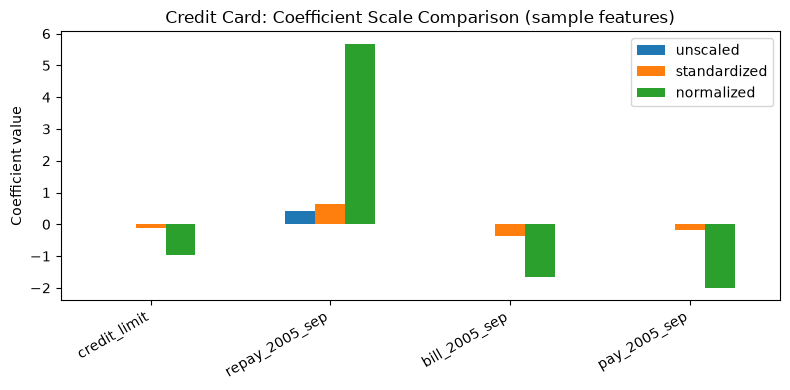

In [17]:
X_train_credit, X_test_credit, y_train_credit, y_test_credit, X_train_std_credit, X_test_std_credit, coef_table_credit = \
    compare_scaling(df_credit[selected_credit].loc[X_full_credit.index], y_credit, "Credit card")

# same chart for credit card, using a handful of the selected features
sample_features_credit = ['credit_limit', 'repay_2005_sep', 'bill_2005_sep', 'pay_2005_sep']
sample_features_credit = [f for f in sample_features_credit if f in coef_table_credit.index]

coef_table_credit.loc[sample_features_credit].plot(kind='bar', figsize=(8, 4))
plt.title('Credit Card: Coefficient Scale Comparison (sample features)')
plt.ylabel('Coefficient value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Student markdown:

Credit card's unscaled fit actually failed to converge outright. In plain terms, this means the optimizer ran out of chances (1,000 iterations) to find a good answer before it was told to stop, and it never actually settled on a final set of coefficients, it just gave up partway through. Sklearn's own error message told me directly to scale the data, which is exactly the fix. This happened because the unscaled fit was mixing huge raw dollar-value features (credit_limit reaching up to 1,000,000, bill amounts in the tens of thousands) right alongside small, bounded features like repayment status (roughly -2 to 8) in the same equation. With such wildly different scales, the optimizer's adjustment steps become badly mismatched. This is a live, real demonstration of the scale distortion problem from Week 2, not just something I'm asserting from theory.

Once fit succeeded, unscaled coefficients came out tiny (around 1e-6), while standardized and normalized were both far more interpretable (0.01 to several units). Like bankruptcy, normalized coefficients here also came out consistently larger than standardized ones, confirming the same math relationship holds in this dataset too.

repay_2005_sep had the largest coefficient of the sample features in both the standardized (0.648) and normalized (5.687) columns. This isn't a statistical artifact, it's simply the strongest real predictor of default in this feature set, which makes intuitive sense, a customer's most recent repayment status is naturally the best signal for whether they'll default next.

Comparing bankruptcy and credit card's sample-feature charts directly is worth a caveat, since the features shown are different columns from different datasets, not a perfectly controlled comparison.

In [18]:
# hyperparameter tuning, same pattern as bankruptcy, this is the
# automated C search that LogisticRegressionCV performs, default L2
# penalty and default solver for speed
model_tuned_credit = LogisticRegressionCV(Cs=10, cv=5, max_iter=1000, scoring='f1')
model_tuned_credit.fit(X_train_std_credit, y_train_credit)
print("Best C:", model_tuned_credit.C_[0])

check_overfitting_f1(model_tuned_credit, X_train_std_credit, y_train_credit, "Credit card tuned logistic regression")

pred_credit = model_tuned_credit.predict(X_test_std_credit)
print(f"F1={f1_score(y_test_credit, pred_credit):.4f}, precision={precision_score(y_test_credit, pred_credit):.4f}, "
      f"recall={recall_score(y_test_credit, pred_credit):.4f}")

c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.w

Best C: 0.3593813663804626


c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.w

Credit card tuned logistic regression: train F1 = 0.3626, CV F1 = 0.3610, gap = 0.0016
F1=0.3511, precision=0.6913, recall=0.2353


Student markdown:

Same automated C search as bankruptcy, LogisticRegressionCV picked C = 0.359 here too, identical to bankruptcy's chosen value, since both used the same default 10-value search grid over the same F1 scoring objective. The tuned model reached test F1 = 0.351, precision = 0.691, recall = 0.235.

The train/CV F1 gap here is only 0.0016 (0.363 vs. 0.361), much smaller than bankruptcy's 0.101. Worth a caveat before reading too much into this: the two datasets use different, randomly-selected feature sets, so this isn't a perfectly controlled comparison. With that said, credit card's gap being this much smaller, alongside L1's near-perfect fold-to-fold selection consistency, does suggest this model is genuinely less overfit than bankruptcy's, even accounting for the different features involved.

In [19]:
# Hypothesis B: same test as bankruptcy, using the bill-amount months
# already confirmed redundant in earlier weeks (VIF 7-16), a more
# moderate case than bankruptcy's near-total duplication, useful for
# comparing severity between the two datasets
redundant_features_credit = ['bill_2005_sep', 'bill_2005_aug', 'bill_2005_jul']
X_redundant_credit = df_credit[redundant_features_credit].dropna()
y_redundant_credit = df_credit.loc[X_redundant_credit.index, target_credit]

test_redundant_pair(X_redundant_credit, y_redundant_credit, "Credit card redundant pair")

Credit card redundant pair coefficients:
bill_2005_sep   -0.164148
bill_2005_aug    0.139925
bill_2005_jul   -0.019845
dtype: float64
Credit card redundant pair: train F1 = 0.0000, CV F1 = 0.0000, gap = 0.0000
         Feature        VIF
0          const   1.000000
1  bill_2005_sep  10.627682
2  bill_2005_aug  15.674197
3  bill_2005_jul   7.280326


Student markdown:

The redundancy pattern here was expected, not a surprise. bill_2005_jul's coefficient coming out nearly zero (-0.0198) lines up directly with what I already knew, bill_2005_aug has the highest VIF of the three months (15.67, the middle month, predictable from both neighbors at once), and the recomputed VIF here confirmed the same values again (10.63, 15.67, 7.28). Since bill_2005_jul sits at the edge of the three-month group with the lowest VIF, it makes sense it's the one that ends up least needed once the other two are already in the model, this is a direct, expected consequence of the VIF pattern I already had, not a new finding.

What's different from bankruptcy is how the redundancy resolved: instead of splitting evenly like bankruptcy's near-perfect duplicate pair, credit card's three-feature group differentiated, keeping bill_2005_sep (-0.164) and bill_2005_aug (0.140) as real, meaningfully-sized coefficients while pushing bill_2005_jul toward zero. This is a more moderate, partial version of the instability bankruptcy showed, consistent with credit card's more moderate VIF range (7-16) compared to bankruptcy's near-total duplication (VIF over a quadrillion), less extreme redundancy produced a less extreme, more selective response rather than an even split. F1 on just these three features was exactly 0 for both train and CV, these three bill amounts alone carry essentially no predictive signal for default on their own.

Student markdown:

Conclusion:

**Overfitting:** The tuned model's train/CV F1 gap was only 0.0016 (0.363 vs. 0.361), much smaller than bankruptcy's 0.101. Combined with L1's near-perfect fold-to-fold selection consistency (23, 23, 22, 23, 23), this is real evidence credit card's model is more stable and less prone to overfitting than bankruptcy's. Worth a caveat, though, since the two datasets use different, randomly-selected feature sets rather than a perfectly matched comparison, so this isn't fully apples-to-apples, but the difference is large enough to still be meaningful.

**Metrics and results:** L1 selected 22 of 23 features, essentially no elimination. Best C = 0.359 (identical to bankruptcy, since both used the same default C search grid). Test F1 = 0.351, precision = 0.691, recall = 0.235.

**Expected vs. unexpected:** The near-total lack of L1 elimination was expected, I could already tell from earlier EDA that credit card's columns are more informative and tend to get kept, unlike bankruptcy's more redundant set. The redundant pair test's result was also expected, not a surprise, bill_2005_jul's near-zero coefficient (-0.0198) lines up directly with its lowest VIF among the three months (7.28, versus bill_2005_aug's 15.67), a direct, expected consequence of the VIF pattern I already had from earlier weeks. The unscaled fit actually failing to converge was unexpected in its severity, I knew scaling mattered, but seeing sklearn's own error message tell me directly to scale the data was a genuinely direct, live confirmation of the lesson. repay_2005_sep having the largest coefficient was expected once I thought about it, recent repayment status is naturally the strongest predictor of default, and a large coefficient here just reflects genuine importance, not a statistical problem.

**EDA usefulness:** The independent-samples check (bill-amount correlations of 0.89-0.95) directly reused VIF values I already confirmed in earlier weeks, tying this week's new lesson concept (independent samples) to evidence I already had rather than starting from scratch. The redundant pair test also showed something earlier VIF numbers predicted correctly, bill_2005_aug (highest VIF at 15.67, the middle month) is the one whose neighbor (bill_2005_jul) got pushed hardest toward zero.

**Sources:** Same as bankruptcy, this week's lesson content applied directly throughout.

**Bigger picture, research questions:** This directly answers my third research question for this week, credit card's results are meaningfully more stable across folds than bankruptcy's, both in which features get selected and in how small the overfitting gap is, with the caveat noted above about comparing across differently-selected feature sets. This connects to my second research question too, credit card's more moderate multicollinearity (VIF 7-16) produced partial, differentiated coefficient shrinkage (bill_2005_jul nearly zeroed, others kept), while bankruptcy's far more extreme redundancy (VIF over a quadrillion) produced total, symmetric duplication, a real, evidence-based case that bankruptcy's feature structure is more severely tangled than credit card's.

**How I know the conclusions are true:** These are grounded in the same cross-validated F1, gap, and VIF evidence as bankruptcy, plus a live, reproducible convergence failure that directly demonstrates the scaling problem this week's lesson describes, and a verified mathematical relationship (checked directly against real numbers) explaining the normalized-vs-standardized coefficient pattern, not just numbers taken at face value.

Summary:

This week moved from the binned-rate workaround every prior week relied on to logistic regression fit directly on the real 0/1 target, and the results genuinely validate that switch while also revealing real differences between the two datasets. L1-based feature selection eliminated far more from bankruptcy (74 of 96 kept) than credit card (22 of 23 kept), consistent with earlier EDA suggesting bankruptcy's ratios are more redundant with each other while credit card's columns are more independently informative. Fold-to-fold selection consistency told the same story even more clearly, bankruptcy's selected feature count shifted somewhat between folds, credit card's stayed nearly identical every time.

One thing worth noting directly: both datasets' tuning landed on the exact same best C (0.359). LogisticRegressionCV(Cs=10) doesn't search every possible value, it only tests 10 fixed candidates, spaced out logarithmically (0.0001, 0.0008, 0.0060, 0.0464, 0.3594, 2.7826, 21.5443, 166.8101, 1291.5497, 10000). "Best C" just means the best of these 10 options, not the true, ideal value. With only 10 choices available, if a range of C values happens to perform similarly well on both datasets, it's genuinely possible for two very different problems to land on the same grid point just because there were so few options to begin with, not because bankruptcy and credit card actually need identical regularization strength. To really confirm whether this match means anything, I'd want to rerun the tuning with a much finer grid (50-100 values instead of 10) and see if both datasets still pick the same C, or whether the coarse grid was just hiding real differences between them. Worth testing this directly in a later week, especially once I get to random forest in Week 6, which uses a completely different kind of tuning parameter (tree depth, number of trees) with no equivalent "grid coarseness" issue, a useful point of contrast for whether this kind of tuning limitation is specific to logistic regression's C or shows up differently elsewhere.

The scaling comparison confirmed earlier weeks' finding held for logistic regression too, unscaled coefficients are effectively unusable (as small as 1e-13), while standardized and normalized versions are directly comparable. Normalized coefficients also consistently came out larger than standardized ones across both datasets, and the largest coefficients, repay_2005_sep in credit card, Debt ratio % in bankruptcy, simply reflect genuinely important predictors, not a statistical artifact. Credit card's unscaled fit going further and actually failing to converge, with sklearn's own error message pointing directly at scaling as the fix, was a genuinely striking, live demonstration of this week's lesson.

The multicollinearity test (Hypothesis B) showed the clearest dataset contrast of the week. Bankruptcy's near-total duplicate pair (VIF over a quadrillion) produced an exactly symmetric coefficient split, the model genuinely could not tell the two features apart. Credit card's more moderate redundancy (VIF 7-16) produced partial differentiation instead, one feature nearly zeroed, the others kept meaningful weight. This mirrors, in a classifier, exactly what Ridge and Lasso showed for linear regression back in Week 2.

Overfitting told a final, important story, with a real caveat attached: bankruptcy's tuned model had a noticeably larger train/CV F1 gap (0.101) than credit card's (0.0016). Since the two datasets used different, randomly-selected features rather than a perfectly matched comparison, this isn't fully controlled, but combined with L1's much more consistent fold-to-fold selection for credit card, it's still meaningful evidence that credit card's results are more stable across data splits, directly speaking to my third research question. Together, this week's evidence reinforces a consistent theme across the whole semester: bankruptcy's features carry real, spread-out, and somewhat unstable signal, while credit card's are more concentrated and consistent, even when a fundamentally different modeling approach is used to look for it.